In [7]:
import numpy as np
import os
from learn_s_hat_toy import make_srs
import copy
from gould_2026.estimator import ArrayWithTime
import matplotlib.pyplot as plt
import pandas as pd

In [49]:
output = None
u_function = 'curvy spins'

In [52]:
def f(u_function='curvy spins', n_runs=100):
    rng = np.random.default_rng(0)
    srs = make_srs(copy.deepcopy(rng), n_runs=n_runs, u_function=u_function, show_tqdm=True, n_rotations=100)
    return rng, srs

rng, srs = f(u_function=u_function, n_runs=5)


  0%|          | 0/5 [00:00<?, ?it/s]

/home/jgould/Documents/AdaptiveLatents/adaptive_latents/regressions.py:254: UserWarning: ignoring non-finite input
  warnings.warn("ignoring non-finite input")
INFO:2025-11-20 20:24:33,108:jax._src.xla_bridge:808: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2025-11-20 20:24:33,108  Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
/home/jgould/Documents/AdaptiveLatents/adaptive_latents/regressions.py:264: UserWarning: history is full, overwriting old observations
  warnings.warn("history is full, overwriting old observations")


caching value in: /mnt/data/al_cache/spinning_toy_458226941178011.pickle
retreiving cache from: /mnt/data/al_cache/spinning_toy_458226941178011.pickle


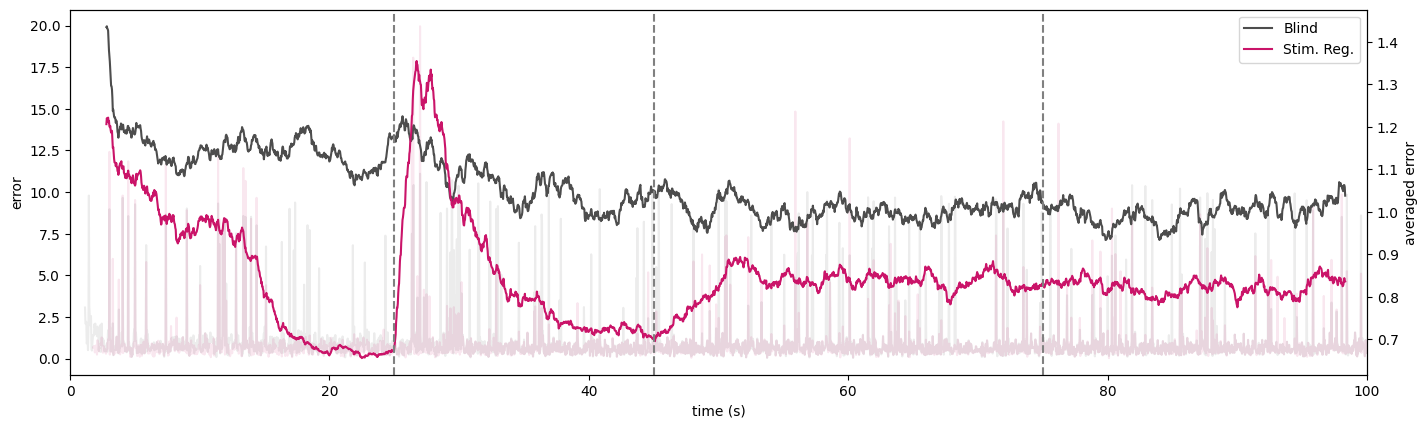

In [51]:
%matplotlib inline
def square_err_array(errs):
    lengths = [len(e.t) for e in errs]
    common_length = min(lengths)
    longest_idx = np.argmax(lengths)
    # a = [np.linalg.norm(e.slice(slice(-common_length, None))**2, axis=1) for e in errs]
    # t = errs[0].slice(slice(-common_length, None)).t
    # return ArrayWithTime(a, t)

    max_length = max(lengths)

    assert np.std(np.vstack([e.t[-common_length:] for e in errs]), axis=0).max() < 1e-10

    filled_errors = []
    for e in errs:
        early_nans = np.array([e[0] * np.nan] * (max_length - len(e))).reshape(-1,3)
        padded_e = np.vstack([np.squeeze(early_nans), e])
        filled_errors.append(padded_e)


    a = np.squeeze([np.linalg.norm(e, axis=1) for e in filled_errors])
    t = errs[longest_idx].t
    good_idx = np.nonzero(np.isnan(a).sum(axis=0) < int(a.shape[0] * .75))[0][0]
    good_idx = 10
    ret = ArrayWithTime(a[:,good_idx:], t[good_idx:])
    return ret


# fig, ax = plt.subplots(figsize=np.array((56,23.6))/5, layout='constrained')
fig, ax = plt.subplots(figsize=np.array((17,5))/1.2, layout='constrained')

ax2 = ax.twinx()

kernel = np.hstack([np.zeros(50), np.ones(51)])
# kernel = np.ones(51)
kernel = kernel / kernel.sum()
time_kernel = kernel * 0
time_kernel[len(kernel)//2] = 1

errs = square_err_array([sr.log['pred_error'] for sr in srs['unaware of stim']])
mean_errors_unaware = np.nanmean(errs, axis=0)
ax.plot(errs.t, errs[0], label='unaware (single trial)', color='#4d4d4dff', alpha=.1,)
smoothed_mean_errs_unaware = ArrayWithTime(np.convolve(mean_errors_unaware, kernel, 'valid'), np.convolve(errs.t, time_kernel, 'valid'))
ax2.plot(smoothed_mean_errs_unaware.t, smoothed_mean_errs_unaware, label='unaware (averaged, smoothed)', color='#4d4d4dff')

errs = square_err_array([sr.log['pred_error'] for sr in srs['learning from stim']])
mean_errors_aware = np.nanmean(errs, axis=0)
ax.plot(errs.t, errs[0], label='aware (single trial)', color='#ca1469ff', alpha=.1)
smoothed_mean_errs_aware = ArrayWithTime(np.convolve(mean_errors_aware, kernel, 'valid'), np.convolve(errs.t, time_kernel, 'valid'))
ax2.plot(smoothed_mean_errs_aware.t, smoothed_mean_errs_aware, label='aware (averaged, smoothed)', color='#ca1469ff')

ax2.axvline(25, color='gray', linestyle='--')
ax2.axvline(45, color='gray', linestyle='--')
ax2.axvline(75, color='gray', linestyle='--')

ax.set_xlabel('time (s)')
ax.set_ylabel('error')
ax2.set_ylabel('averaged error')
ax2.legend(['Blind','Stim. Reg.'],loc='upper right')
# ax.legend(loc='upper left')
ax.set_xlim([0,100])
ax2.set_xlim([0,100])

# ax.set_ylim([0,290])
# ax2.set_ylim([0,13])

# x = np.linspace(0,50,200)
# ax2.plot(x+50,  % (2 * np.pi))

if output is not None:
    fig.savefig(output)


In [34]:

df = pd.DataFrame([
    {'condition': 'unaware of stim', 'errors': mean_errors_unaware},
    {'condition': 'learning from stim', 'errors': mean_errors_aware},
])

df['overall_err_mean'] = df['errors'].apply(lambda x: np.nanmean(x.slice_by_time(slice(None,None))))
df['overall_err_std'] = df['errors'].apply(lambda x: np.nanmean(x.slice_by_time(slice(None,None))))
df['last_rotation_err_mean'] = df['errors'].apply(lambda x: np.nanmean(x.slice_by_time(slice(75,None))))
df['last_rotation_err_std'] = df['errors'].apply(lambda x: np.nanstd(x.slice_by_time(slice(75,None))))
df['initial_fit_err_mean'] = df['errors'].apply(lambda x: np.nanmean(x.slice_by_time(slice(None,25))))
df['initial_fit_err_std'] = df['errors'].apply(lambda x: np.nanstd(x.slice_by_time(slice(None,25))))
del df['errors']

df


,condition,overall_err_mean,overall_err_std,last_rotation_err_mean,last_rotation_err_std,initial_fit_err_mean,initial_fit_err_std
0,unaware of stim,1.502572,1.502572,1.328563,0.423451,1.955053,0.467354
1,learning from stim,1.097643,1.097643,1.010507,0.301672,1.125669,0.459719


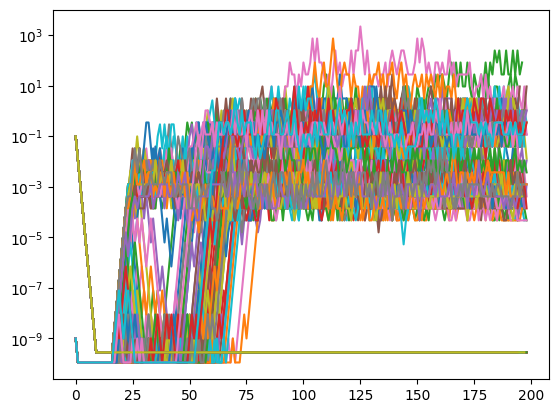

In [5]:
fig, ax = plt.subplots()
for sr in srs['learning from stim']:
    sr.stim_reg.plot_length_scales(ax)